In [12]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from src.data_loader import VesselDataLoader
from src.feature_evaluation import FeatureEvaluator

In [17]:
# Path to your raw telemetry
raw_data_file1 = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"
raw_data_file2 = root_path / "data" / "raw" / "Wembley_voy_236.csv"

# Instantiate
loader1 = VesselDataLoader(raw_data_file1)
loader2 = VesselDataLoader(raw_data_file2)

# Load and clean the data
df1 = loader1.load_and_clean()
df2 = loader2.load_and_clean()

base_features = ['AE_POWER(kW)', 'SHIP SPEED(knots)', 'NUM_GENERATORS']
engineered_features = ['GEN_TRANSITION', 'LOAD_SYMMETRY_ERROR', 'ROT_DEG_PER_MIN', 'ENERGY_INTENSITY', 'POWER_TV_ENERGY', 'PF_EFFECTIVE', 'PF_DERIVATIVE']
all_features = base_features + engineered_features

Successfully loaded, cleaned, and processed 2880 telemetry rows.
Successfully loaded, cleaned, and processed 3168 telemetry rows.


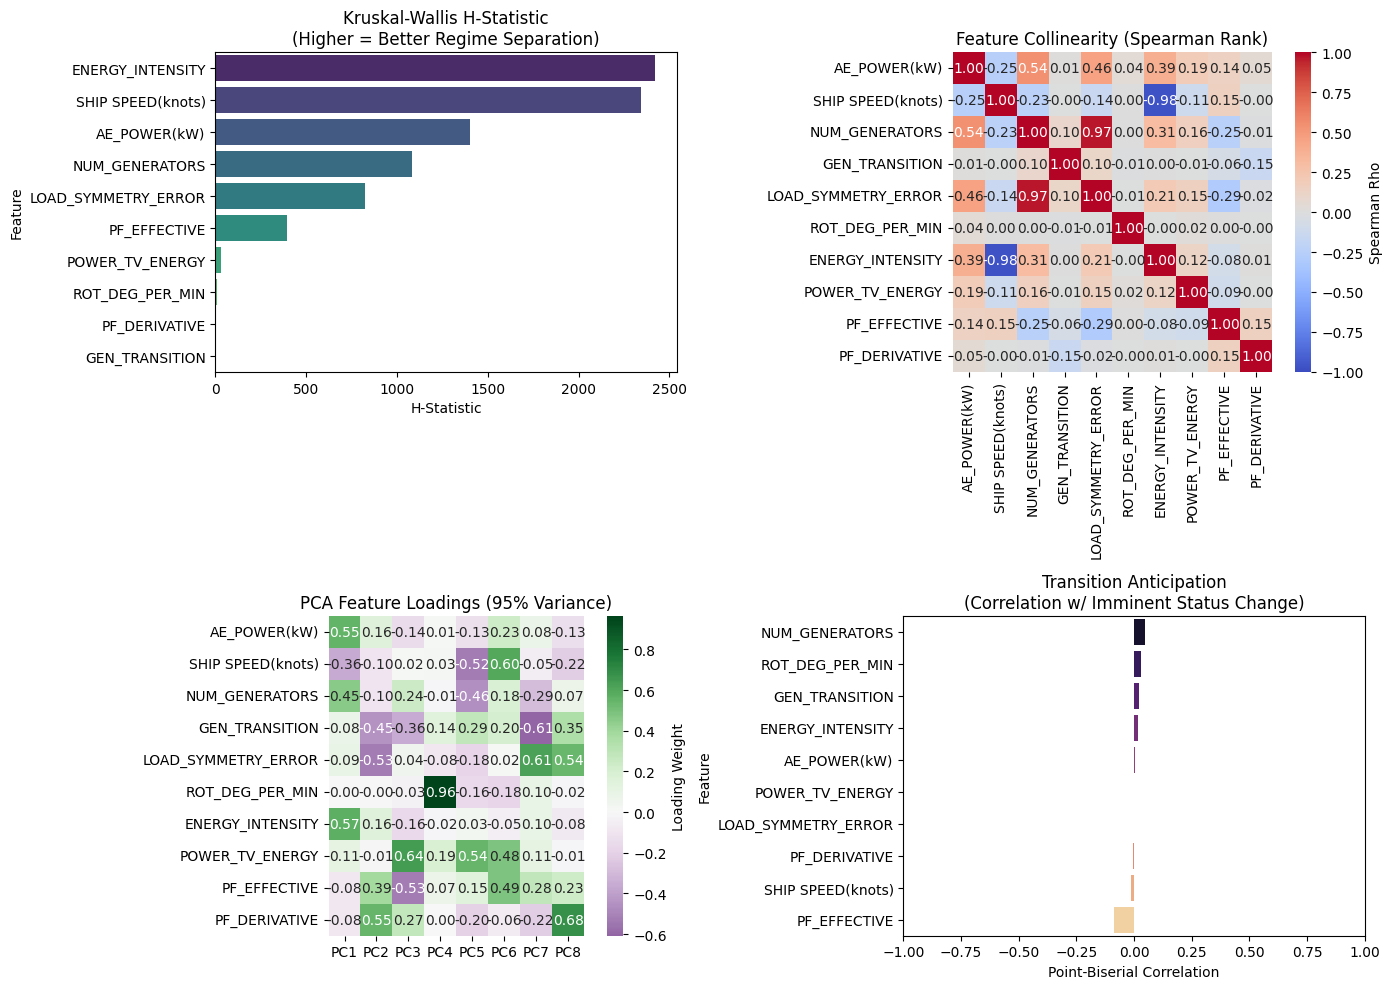

In [18]:
evaluator1 = FeatureEvaluator(df1, target_col='STATUS')

evaluation1=evaluator1.evaluate(all_features, strategy='all')

evaluator1.plot_diagnostics(evaluation1)